# Study 784 — Analyst-Cluster 📈

*For the curious.* The contrarian's favourite: when *everybody* upgrades a stock in the same week, fade it — the sell-side pile-in is the last marginal buyer. We put that trade on NVDA's tape across 39 analyst-upgrade clusters (2016→2025) and asked two plain questions: **does NVDA run up into the cluster?** and **does it fade after?** The answer to the fade is a loud, wrong-signed *no*.

## The claim, and the honest proxy

> **LABELLED PROXY.** There's no free point-in-time analyst-upgrade feed here, so the *cluster week* is proxied by **NVDA's real quarterly earnings week** — the canonical trigger of a same-week price-target-hike wave. The earnings dates are real and known ~3-4 weeks ahead (zero look-ahead). The catch, stated up front: this proxy inherits **post-earnings drift** as a confound.

We measure NVDA's **abnormal** return (NVDA − SPY, total-return) so we're not just measuring the fact that NVDA went up ~300× over the decade.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from analyst_cluster import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching NVDA + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} clusters resolved")


panel loaded; 39 of 39 clusters resolved


## The clusters we test (LABELLED PROXY = NVDA earnings weeks)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['cluster_tag', 'anchor_date (PROXY)'])

,cluster_tag,anchor_date (PROXY)
0,2016-Feb,2016-02-17
1,2016-May,2016-05-12
2,2016-Aug,2016-08-11
3,2016-Nov,2016-11-10
4,2017-Feb,2017-02-09
5,2017-May,2017-05-09
6,2017-Aug,2017-08-10
7,2017-Nov,2017-11-09
8,2018-Feb,2018-02-08
9,2018-May,2018-05-10


## The picture: mean cumulative abnormal return around the cluster

Offset 0 is the cluster/earnings day. Left of zero is the *run-up*; right of zero is the *fade* window the folklore says to short. If the fade were real the line would turn **down** after 0. It doesn't.

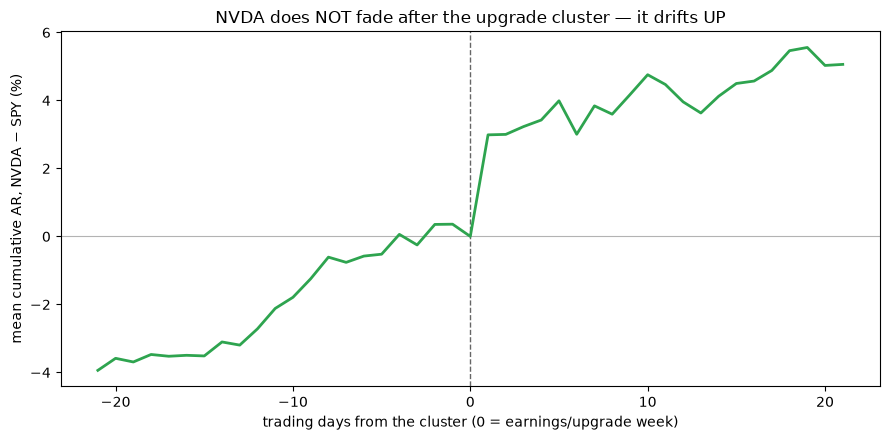

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#2ea44f', lw=2)
ax.set_xlabel('trading days from the cluster (0 = earnings/upgrade week)')
ax.set_ylabel('mean cumulative AR, NVDA − SPY (%)')
ax.set_title('NVDA does NOT fade after the upgrade cluster — it drifts UP')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 2-week run-up | +2.29% | +2.34 | 26/39 |
| 1-month run-up | +5.27% | +3.56 | 30/39 |
| **2-week fade** | **+4.76%** | **+2.13** | 23/39 |
| 1-month fade | +5.06% | +1.96 | 23/39 |

The 'fade' is **wrong-signed**: after the cluster NVDA *gains* +4.76% vs SPY over two weeks (*t* = +2.13). A contrarian who shorted it would have lost that, 39 times over. Note the trap, though: NVDA is one hand-picked mega-winner, so *random* 2-week windows already beat SPY by ~+2.0% — read every number against that, not zero.

In [4]:
rows = [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk fade','post_s'),('1mo fade','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<12s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

2wk run-up   n=39  mean=+2.292%  t=+2.339  hit 26/39
1mo run-up   n=39  mean=+5.274%  t=+3.562  hit 30/39
2wk fade     n=39  mean=+4.756%  t=+2.126  hit 23/39
1mo fade     n=39  mean=+5.060%  t=+1.964  hit 23/39


## So what?

The *fade the analyst cluster* trade is busted on NVDA — the stock **drifts up** after the cluster, so fading it loses money. The only real effect in the data is a single-name **post-earnings drift** sitting on top of NVDA's +2%/fortnight baseline — neither the claim, nor a generalizable edge. Verdict: **Weak signal (wrong-signed), Mirage tradability.** The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control.